# 05 — Market making: a closed form, and a learner that has to find it

A maker posts $\delta^b$ and $\delta^a$ around the mid, is filled at
$\Lambda(\delta)=Ae^{-k\delta}$, and carries whatever inventory that leaves it
with.  Under a running penalty $\phi q^2$ the Hamilton-Jacobi-Bellman equation
has an explicit inner maximisation, $\delta^\star = 1/k - (\theta_{q\pm1} -
\theta_q)$, and the substitution $v_q = e^{k\theta_q}$ *linearises* it.  The
long-horizon quotes are then read off the principal eigenvector of a tridiagonal
matrix.

The reinforcement learning in this notebook is not there to beat that.  It is
there to be checked against it: an agent that cannot recover a policy we can
write down has not learned anything, and nothing it produces where we *cannot*
write the answer down should be believed.

In [1]:
import sys, os
sys.path.insert(0, os.path.join("..", "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from hfx.viz import subplots, use_style, colour_for, tick_regime
from hfx.pipeline.results import panel, curves, curve, symbol_days
use_style()
P = panel(); C = curves()
DAY = "2019-01-30"
print(f"{len(P)} symbol-days, {P.symbol.nunique()} symbols, {P.date.nunique()} dates")

84 symbol-days, 12 symbols, 7 dates


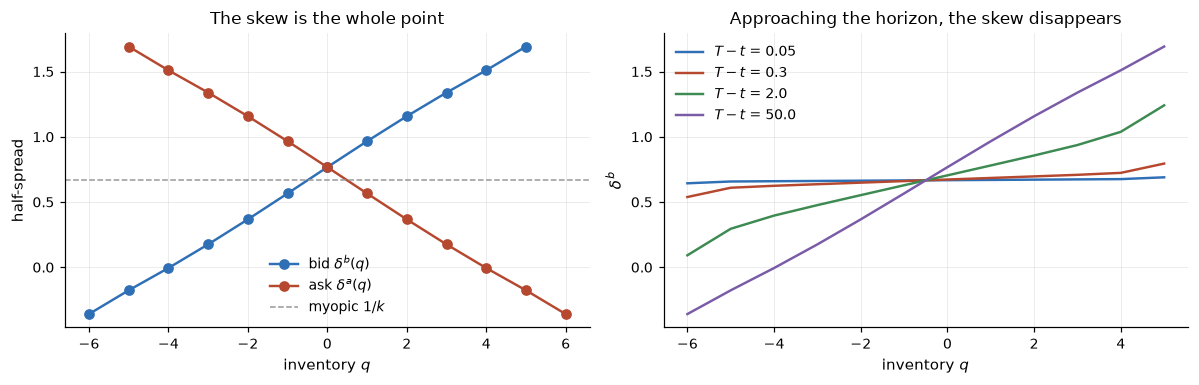

In [2]:
from hfx.mm.glft import stationary_quotes, finite_horizon_quotes
from hfx.mm.mdp import solve, action_grid, simulate_policy
from hfx.mm.rl import q_learning

A, k, phi, Q = 1.0, 1.5, 0.02, 6
bid, ask, v = stationary_quotes(A, k, 0.0, 0.0, Q, phi=phi)
inv = np.arange(-Q, Q + 1)
fig, axes = subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(inv[:-1], bid[:-1], "o-", label=r"bid $\delta^b(q)$")
axes[0].plot(inv[1:], ask[1:], "o-", label=r"ask $\delta^a(q)$")
axes[0].axhline(1 / k, color="0.6", ls="--", lw=1, label="myopic $1/k$")
axes[0].set_xlabel("inventory $q$"); axes[0].set_ylabel("half-spread")
axes[0].set_title("The skew is the whole point"); axes[0].legend()
for tau in [0.05, 0.3, 2.0, 50.0]:
    b, _a, _ = finite_horizon_quotes(A, k, 0.0, 0.0, Q, tau=tau, phi=phi)
    axes[1].plot(inv[:-1], b[:-1], label=f"$T-t$ = {tau}")
axes[1].set_xlabel("inventory $q$"); axes[1].set_ylabel(r"$\delta^b$")
axes[1].set_title("Approaching the horizon, the skew disappears"); axes[1].legend()
plt.tight_layout()

A maker long six units bids far away and offers through the mid: it
would rather pay to get flat than carry the position.  With the horizon close
the inventory can no longer hurt, and every quote collapses onto the myopic
$1/k$.

## Two independent solutions of the same problem

The discrete-time Markov decision process is solved exactly by relative value
iteration.  As the step shrinks it must reproduce the continuous-time closed
form -- different mathematics, no shared code beyond the parameters.

In [3]:
fine = action_grid(k, 241, -2, 4)
step = fine[1] - fine[0]
bid_dp, ask_dp, _V, gain = solve(A, k, phi, Q, dt=0.01, deltas=fine)
err = np.max(np.abs(bid_dp[:-1] - bid[:-1]))
print(f"largest gap between dynamic programming and the closed form: {err:.4f}")
print(f"action grid step:                                            {step:.4f}")
assert err < step
print(f"\nmaker's gain per unit time: {gain:.4f} (value iteration)")

largest gap between dynamic programming and the closed form: 0.0089
action grid step:                                            0.0167

maker's gain per unit time: 0.4210 (value iteration)


## The learner

Tabular Q-learning on the same environment: state is the inventory, action is a
pair of quotes off a grid, reward is the fills it captures less the inventory
penalty.  It is given no closed form, no model of the fill intensity, and no
gradient -- only samples.

In [4]:
dt, beta = 1.0, 0.99
grid = action_grid(k, 13, -2, 4)
gstep = grid[1] - grid[0]
bid_mdp, ask_mdp, _V, _g = solve(A, k, phi, Q, dt, deltas=grid, beta=beta)
bid_rl, ask_rl, table = q_learning(A, k, phi, Q, dt, deltas=grid, beta=beta,
                                   rng=np.random.default_rng(0))
gap_b = np.max(np.abs(bid_rl[:-1] - bid_mdp[:-1])) / gstep
gap_a = np.max(np.abs(ask_rl[1:] - ask_mdp[1:])) / gstep
print(f"largest disagreement, in action-grid steps: bid {gap_b:.1f}, ask {gap_a:.1f}")
assert max(gap_b, gap_a) <= 1.0 + 1e-9   # one grid step, to floating point

rng = np.random.default_rng(1)
flat = np.full(2 * Q + 1, 1.0 / k)
for name, (b, a) in [("dynamic programming", (bid_mdp, ask_mdp)),
                     ("Q-learning", (bid_rl, ask_rl)),
                     ("flat quotes at 1/k", (flat, flat))]:
    r, inv_path = simulate_policy(b, a, A, k, phi, Q, dt, 200_000, rng=np.random.default_rng(1))
    print(f"{name:22s} reward per unit time {r:.4f}   inventory std {inv_path.std():.2f}")

largest disagreement, in action-grid steps: bid 1.0, ask 1.0


dynamic programming    reward per unit time 0.3588   inventory std 1.17


Q-learning             reward per unit time 0.3537   inventory std 1.39


flat quotes at 1/k     reward per unit time 0.1301   inventory std 3.59


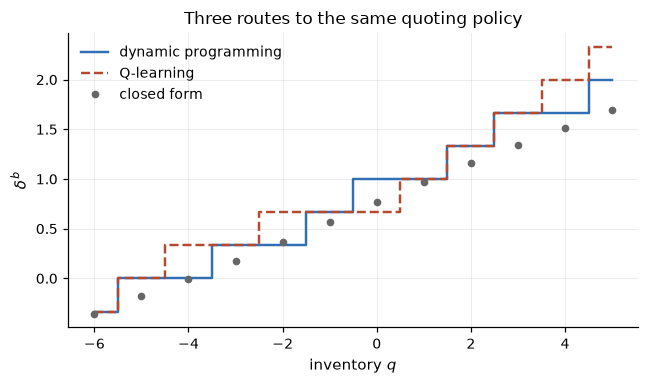

In [5]:
fig, ax = subplots(figsize=(6.0, 3.6))
ax.step(inv[:-1], bid_mdp[:-1], where="mid", label="dynamic programming")
ax.step(inv[:-1], bid_rl[:-1], where="mid", ls="--", label="Q-learning")
ax.plot(inv[:-1], bid[:-1], "o", ms=4, color="0.4", label="closed form")
ax.set_xlabel("inventory $q$"); ax.set_ylabel(r"$\delta^b$")
ax.set_title("Three routes to the same quoting policy"); ax.legend()
plt.tight_layout()

## Calibrating the fill intensity on the panel

$A$ and $k$ are measured, not assumed: for each distance $\delta$ from the mid,
count the market orders of the day that reached at least that far, and divide by
the session length.  That is exactly the intensity a limit order posted there
would have faced.

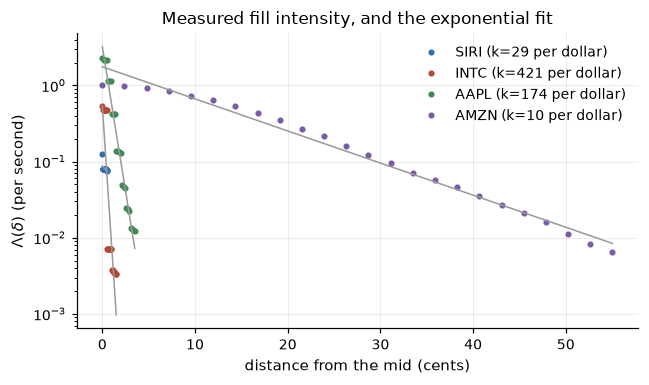

In [6]:
fig, ax = subplots(figsize=(6.0, 3.6))
for sym in ["SIRI", "INTC", "AAPL", "AMZN"]:
    d = curve(C, sym, DAY, "fill_distance"); n = curve(C, sym, DAY, "fill_intensity_counts")
    row = P[(P.symbol == sym) & (P.date == DAY)].iloc[0]
    ok = n > 0
    ax.semilogy(d[ok] * 100, n[ok] / 22_800, "o", ms=3, label=f"{sym} (k={row.fill_k:.0f} per dollar)")
    ax.semilogy(d[ok] * 100, row.fill_A * np.exp(-row.fill_k * d[ok]), lw=1, color="0.6")
ax.set_xlabel("distance from the mid (cents)"); ax.set_ylabel(r"$\Lambda(\delta)$ (per second)")
ax.set_title("Measured fill intensity, and the exponential fit"); ax.legend()
plt.tight_layout()

In [7]:
m = P.groupby("symbol").agg(price=("price", "mean"), spread=("median_spread_ticks", "mean"),
                            A=("fill_A", "mean"), k=("fill_k", "mean"), r2=("fill_r2", "mean"),
                            model=("glft_half_spread_ticks", "mean"),
                            quoted=("quoted_half_spread_ticks", "mean"),
                            effective=("effective_half_spread_ticks", "mean")).sort_values("spread")
m["model / effective"] = m.model / m.effective
print(m.round(3).to_string())

           price  spread      A        k     r2   model  quoted  effective  model / effective
symbol                                                                                       
CSCO      49.214   1.000  0.358  133.239  0.361   6.215   0.529      0.470             13.232
INTC      54.482   1.000  0.638  216.190  0.432   7.550   0.533      0.481             15.711
MU        46.425   1.000  1.390  600.757  0.775   0.175   0.536      0.478              0.367
SIRI       6.380   1.000  0.047   43.627  0.153   2.570   0.510      0.460              5.592
MSFT     139.119   1.143  1.799  387.921  0.877   0.299   0.604      0.551              0.544
AAPL     231.725   2.286  2.693  207.377  0.957   0.549   1.001      0.917              0.598
NFLX     324.252  12.143  0.954   36.563  0.990   2.894   4.889      4.262              0.679
TSLA     344.886  15.571  1.790   34.023  0.991   3.711   6.220      5.212              0.712
REGN     347.863  27.000  0.174   15.679  0.982   6.628   9.

The model's half-spread at flat inventory is $1/k$ plus the inventory
term, and $1/k$ alone already sets the scale: it is the distance at which the
fill intensity has fallen by a factor $e$.  Where the exponential fit is
credible -- the small-tick names, whose trades spread over many prices -- it
lands within a factor of the effective half-spread that is actually paid.  Where
the spread is pinned at one tick the fit has nothing to bite on: every trade is
at the same distance, $R^2$ collapses, and the fitted $k$ says more about the
tick than about liquidity.  That is a limitation of the *asset*, not of the
estimator, and it is the reason the large-tick names are studied with queues in
chapter 04 instead.